# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Load data from simulation of system dynamic model. 
% Data file contains the variables: model dT t u x z
load readonly/simOut.mat

% Determine number of states and timesteps
[nx,nt] = size(x); 

% Reserve storage for results
xhatEKFstore  = zeros(nx,nt);
boundEKFstore = zeros(nx,nt);
xhatCKFstore  = zeros(nx,nt);
boundCKFstore = zeros(nx,nt);

% Covariance values
SigmaX0 = 0.1*eye(nx,nx); % uncertainty of initial state
xhat0   = zeros(nx,1);

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

### Helper functions for the extended Kalman filter
The next notebook cells implement the initialization and iteration functions for the EKF.

In [3]:
% EKF initialization function, called once at the beginning of the simulation
function ekfData = initEKF(xhat0,SigmaX0,priorU,model)
  ekfData.xhat   = xhat0;        % Initial state description  
  ekfData.SigmaX = SigmaX0;      % Initial estimation-error covariance 
  ekfData.SigmaV = model.SigmaV; % Sensor-noise covariance 
  ekfData.SigmaW = model.SigmaW; % Process-noise covariance
  ekfData.Sw     = model.Sw;     % Cts-time process-noise covariance
  ekfData.priorU = priorU;       % Previous value of input force
  ekfData.model  = model;        % Store model data structure too
  ekfData.Qbump  = 5;            % In case SigmaX collapses
end

In [4]:
% EKF iteration function, called once every measurement interval
function [xhat,bounds,ekfData] = iterEKF(uk,zk,dT,ekfData)
  model = ekfData.model;
  
  % Get data stored in ekfData structure
  priorU = ekfData.priorU;
  SigmaX = ekfData.SigmaX;
  SigmaV = ekfData.SigmaV;
  SigmaW = ekfData.SigmaW;
  Sw     = ekfData.Sw;
  xhat   = ekfData.xhat;
  
  % EKF Step 0: Compute Ahat[k-1], Bhat[k-1]
  Ahat = [1 dT; -model.k1*dT/model.m-3*model.k2*dT*xhat(1)^2/model.m ...
          1-model.b*dT/model.m];
  Bhat = [0; dT/model.m];
  
  % Step 1a: State estimate time update
  xhat = [1 dT; -model.k1*dT/model.m 1-model.b*dT/model.m]*xhat + ...
         [0; -model.k2*dT*xhat(1)^3/model.m] + ...
         [0; dT/model.m]*priorU;
  
  % Step 1b: Error covariance time update
  %          sigmaminus(k) = Ahat(k-1)*sigmaplus(k-1)*Ahat(k-1)' + ...
  %                          Bhat(k-1)*sigmawtilde*Bhat(k-1)'
  SigmaX = Ahat*SigmaX*Ahat' + Bhat*(Sw/dT)*Bhat'; % default method
  % SigmaX = Ahat*SigmaX*Ahat' + SigmaW;           % alternate method
  
  % Step 1c: Output estimate
  zhat = atan(xhat(1)/model.d);
  
  % Step 2a: Estimator gain matrix
  Chat = [model.d/(model.d^2 + xhat(1)^2) 0]; Dhat = 1;
  SigmaZ = Chat*SigmaX*Chat' + Dhat*SigmaV*Dhat';
  L = SigmaX*Chat'/SigmaZ;
  
  % Step 2b: State estimate measurement update
  r = zk - zhat; % residual.  Use to check for sensor errors...
  if r^2 > 100*SigmaZ, L(:)=0.0; end 
  xhat = xhat + L*r;
  
  % Step 2c: Error covariance measurement update
  SigmaX = SigmaX - L*SigmaZ*L';

  % Q-bump code
  if r^2 > 16*SigmaZ % bad output estimate by 4 std. devs, bump Q 
    fprintf('Bumping SigmaX\n');
    SigmaX = SigmaX*ekfData.Qbump;
  end
  [~,S,V] = svd(SigmaX); % Implement Higham method to help robustness
  HH = V*S*V';
  SigmaX = (SigmaX + SigmaX' + HH + HH')/4; 
  
  % Save data in ekfData structure for next time...
  ekfData.priorU = uk;
  ekfData.SigmaX = SigmaX;
  ekfData.xhat = xhat;
  bounds = 3*sqrt(diag(SigmaX));
end

### Implementing the extended Kalman filter
The next notebook cell implements the main code of the extended Kalman filter.

In [5]:
% Create ekfData structure and initialize variables 
ekfData = initEKF(xhat0,SigmaX0,u(1),model);

% Now, enter loop for remainder of time, where we update the EKF
% once per sample interval
for k = 2:length(t)
  uk = u(k); % "measure" input force
  zk = z(k); % "measure" nonlinear output
  
  % Compute estimate of present state vector and its bounds
  [xhatEKFstore(:,k),boundEKFstore(:,k),ekfData] = iterEKF(uk,zk,dT,ekfData);
end

### Plot simulation outputs from the extended Kalman filter
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

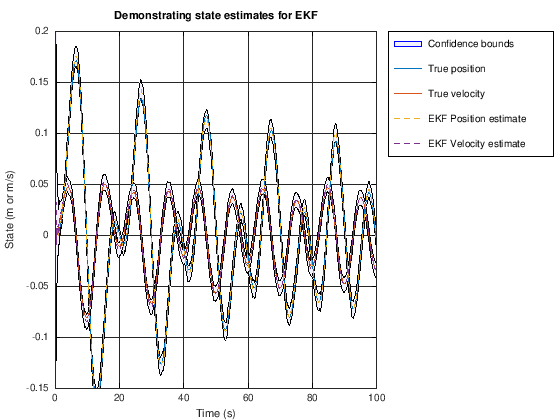

In [6]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatEKFstore-boundEKFstore fliplr(xhatEKFstore+boundEKFstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 

h2 = plot(t,x',t,xhatEKFstore','--'); ylim([-0.15 0.2]);
legend([h2;h1a],{'True position','True velocity','EKF Position estimate',...
  'EKF Velocity estimate','Confidence bounds'},'Location','BestOutside'); 
title('Demonstrating state estimates for EKF'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

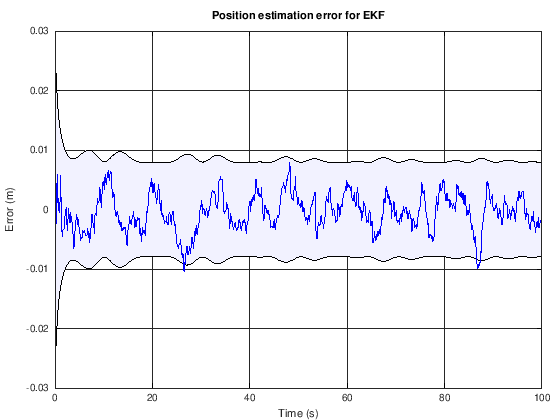

In [7]:
ekfErr = x - xhatEKFstore;
fill([t fliplr(t)],[-boundEKFstore(1,:) fliplr(boundEKFstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ekfErr(1,:),'b');
title('Position estimation error for EKF'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

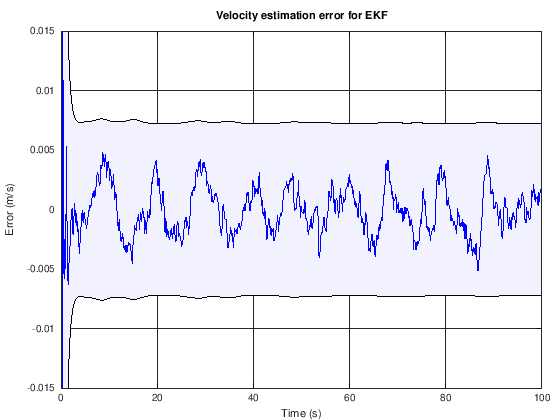

In [8]:
fill([t fliplr(t)],[-boundEKFstore(2,:) fliplr(boundEKFstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ekfErr(2,:),'b'); ylim([-0.015 0.015]);
title('Velocity estimation error for EKF'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 

In [9]:
% Compute and output some statistics
fprintf('RMS state estimation error = %g\n',rms(ekfErr(:)));
ind = find(abs(ekfErr(:))>boundEKFstore(:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundEKFstore(:))*100);

RMS state estimation error = 0.0027576
Time error outside bounds = 0.44955%


### Helper functions for the cubature Kalman filter
The next notebook cells implement the initialization and iteration functions for the CKF.

In [10]:
% CKF initialization function, called once at the beginning of the simulation
function ckfData = initCKF(xhat0,SigmaX0,priorU,model)
  ckfData.xhat   = xhat0;        % Initial state description  
  ckfData.SigmaX = SigmaX0;      % Initial estimation-error covariance 
  ckfData.SigmaV = model.SigmaV; % Sensor-noise covariance 
  ckfData.SigmaW = model.SigmaW; % Process-noise covariance
  ckfData.Sw     = model.Sw;     % Cts-time process-noise covariance
  ckfData.priorU = priorU;       % Previous value of input force
  ckfData.model  = model; % Store model data structure too
  ckfData.Qbump  = 5;     % In case SigmaX collapses
  
  % CKF specific parameters
  nx = length(ckfData.xhat); ckfData.nx = nx; % state-vector length
  nz = 1; ckfData.nz = nz; % measurement-vector length
  nu = 1; ckfData.nu = nu; % input-vector length
  
  ckfData.h = sqrt(nx); % CKF tuning factor  
  Weight1 = 0;          % weighting factors when computing mean
  Weight2 = 1/(2*nx);   % and covariance
  ckfData.Wm = [Weight1; Weight2*ones(2*nx,1)]; % mean
  ckfData.Wc = ckfData.Wm;                     % covar

  % previous value of input
  ckfData.priorU = priorU;
  
  % store model data structure too
  ckfData.model = model;
end

In [11]:
% CKF iteration function, called once every measurement interval
function [xhat,bounds,ckfData] = iterCKF(uk,zk,dT,ckfData)
  model = ckfData.model;
  SQRT = @(x) sqrt(max(0,x)); % "Safe" square root

  % Get data stored in spkfData structure
  priorU = ckfData.priorU;
  SigmaX = ckfData.SigmaX;
  xhat = ckfData.xhat;
  nx = ckfData.nx;
  Wc = ckfData.Wc;
  
  % Step 1a: State estimate time update
  %          - Create xhatminus augmented SigmaX points
  %          - Extract xhatminus state SigmaX points
  %          - Compute weighted average xhatminus(k)

  % Step 1a-1: Create augmented SigmaX and xhat
  [sigmaX,p] = chol(SigmaX,'lower'); 
  if p>0
    fprintf('Cholesky errorin step 1a.  Recovering...\n');
    sigmaX = SQRT(diag(SigmaX));
  end
  % NOTE: sigmaX is lower-triangular

  % Step 1a-2: Calculate SigmaX points (strange indexing of xhata to 
  % avoid "repmat" call, which is very inefficient in MATLAB)
  X = xhat(:,ones([1 2*nx+1])) + ...
       ckfData.h*[zeros([nx 1]), sigmaX, -sigmaX];

  % Step 1a-3: Time update from last iteration until now
  %     stateEqn(xold,current,dT)
  Xx = stateEqn(X,priorU,dT); 
  xhat = Xx*ckfData.Wm;

  % Step 1b: Error covariance time update
  %          - Compute weighted covariance sigmaminus(k)
  %            (strange indexing of xhat to avoid "repmat" call)
  Xs = Xx - xhat(:,ones([1 2*nx+1]));
  SigmaX = Xs*diag(Wc)*Xs';  
  SigmaX = SigmaX + ckfData.Sw*dT/model.m^2*[0 0; 0 1]; % See Lesson 3.1.5
  % Alternate implementation...
  % SigmaX = SigmaX + ckfData.SigmaW;

  % Step 1c: Output estimate
  %          - Compute weighted output estimate zhat(k)
  [sigmaX,p] = chol(SigmaX,'lower'); 
  if p>0
    fprintf('Cholesky error in step 1c.  Recovering...\n');
    sigmaX = SQRT(diag(SigmaX));
  end
  X = xhat(:,ones([1 2*nx+1])) + ckfData.h*[zeros([nx 1]), sigmaX, -sigmaX];
  Z = outputEqn(X,model);
  zhat = Z*ckfData.Wm;

  % Step 2a: Estimator gain matrix
  Zs = Z - zhat(:,ones([1 2*nx+1]));
  SigmaXZ = Xs*diag(Wc)*Zs';
  SigmaZ  = Zs*diag(Wc)*Zs' + ckfData.SigmaV;
  L = SigmaXZ/SigmaZ; 

  % Step 2b: State estimate measurement update
  r = zk - zhat; % residual.  Use to check for sensor errors...
  if r^2 > 100*SigmaZ, L(:)=0.0; end 
  xhat = xhat + L*r;

  % Step 2c: Error covariance measurement update
  SigmaX = SigmaX - L*SigmaZ*L';

  % Q-bump code
  if r^2 > 16*SigmaZ % bad output estimate by 4 std. devs, bump Q 
    fprintf('Bumping SigmaX\n');
    SigmaX = SigmaX*ckfData.Qbump;
  end
  [~,S,V] = svd(SigmaX); % Implement Higham method to help robustness
  HH = V*S*V';
  SigmaX = (SigmaX + SigmaX' + HH + HH')/4; 
  
  % Save data in ekfData structure for next time...
  ckfData.priorU = uk;
  ckfData.SigmaX = SigmaX;
  ckfData.xhat = xhat;
  bounds = 3*sqrt(diag(SigmaX));
  
  % Calculate new states for all of the old state vectors in xold.  
  function xnew = stateEqn(xold,priorU,dT)
    % Compute linear homogeneous part
    xnew = [1 dT; -model.k1*dT/model.m 1-model.b*dT/model.m]*xold;
    % Add on nonlinear and forcing part
    xnew(2,:) = xnew(2,:) - model.k2*dT*xold(1,:).^3/model.m + ...
              dT/model.m*priorU;
  end

  % Calculate cell output voltage for all of state vectors in xhat
  function zhat = outputEqn(xhat,model)
    zhat = atan(xhat(1,:)/model.d);
  end
end

### Implementing the cubature Kalman filter
The next notebook cells implement the main code of the cubature Kalman filter.

In [12]:
% Create spkfData structure and initialize variables 
ckfData = initCKF(xhat0,SigmaX0,u(1),model);

% Now, enter loop for remainder of time, where we update the SPKF
% once per sample interval
for k = 2:length(t)
  uk = u(k); % "measure" input force
  zk = z(k); % "measure" nonlinear output
  
  % Update SOC (and other model states)
  [xhatCKFstore(:,k),boundCKFstore(:,k),ckfData] = iterCKF(uk,zk,dT,ckfData);
end
ckfErr = x - xhatCKFstore;
ckfBnd = boundCKFstore;

### Plot simulation outputs from the cubature Kalman filter
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

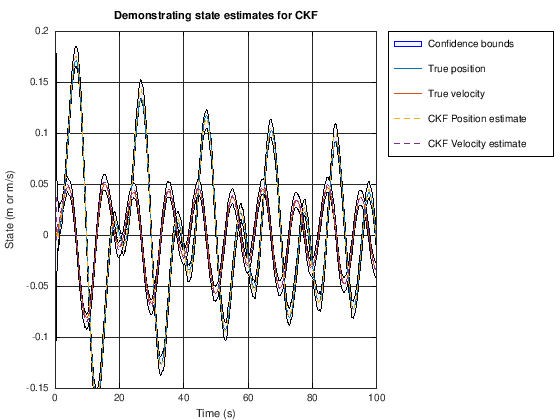

In [13]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatCKFstore-boundCKFstore fliplr(xhatCKFstore+boundCKFstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 

h2 = plot(t,x',t,xhatCKFstore','--'); ylim([-0.15 0.2]);
legend([h2;h1a],{'True position','True velocity','CKF Position estimate',...
  'CKF Velocity estimate','Confidence bounds'},'Location','BestOutside'); 
title('Demonstrating state estimates for CKF'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

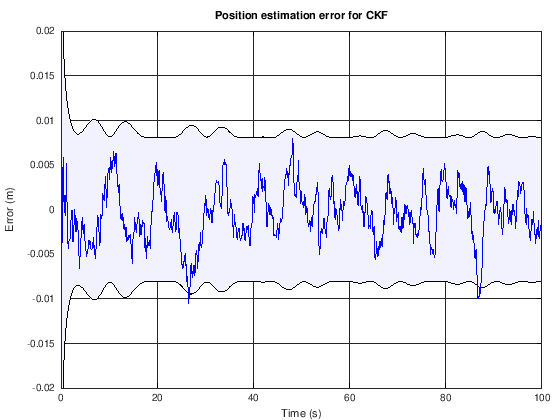

In [14]:
fill([t fliplr(t)],[-boundCKFstore(1,:) fliplr(boundCKFstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ckfErr(1,:),'b'); ylim([-0.02 0.02])
title('Position estimation error for CKF'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

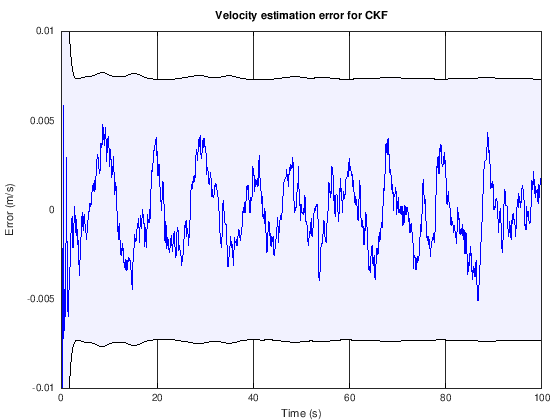

In [15]:
fill([t fliplr(t)],[-boundCKFstore(2,:) fliplr(boundCKFstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ckfErr(2,:),'b'); ylim([-0.01 0.01]);
title('Velocity estimation error for CKF'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 

In [16]:
% Compute and output some statistics
fprintf('RMS state estimation error = %g\n',rms(ckfErr(:)));
ind = find(abs(ckfErr(:))>boundCKFstore(:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundCKFstore(:))*100);

RMS state estimation error = 0.00274328
Time error outside bounds = 0.3996%


In [20]:
rms(ckfErr(1,:))

ans =  0.0030685


In [21]:
ind = find(abs(ckfErr(1,:))>boundCKFstore(1,:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundCKFstore(1,:))*100);

Time error outside bounds = 0.799201%
